# BMW Cars Dataset Analysis - Regression Study

In this project, we analyze a dataset containing detailed information about BMW vehicle listings. The dataset includes 10,781 records and 9 variables, describing characteristics such as model, year of manufacture, selling price, transmission type, mileage, fuel type, road tax, engine size, and fuel economy (mpg).

The objective of this study is to solve a regression problem by predicting the selling price of a vehicle based on its technical and descriptive features. The main path that is to follow will include:  <br>
-> EDA with visualizations <br>
-> building and comparing, tuning **classical ML models** as Linear Regression, Decision Trees, XGBoost, Random Forest <br>
-> building and comparing **Neural Network** architectures <br>
-> applying hyperparameter tuning, cross-validation and regularization <br>
-> drawing conclusions <br>


Dataset can be found here: [bmw](https://www.kaggle.com/datasets/wardabilal/bmw-cars-dataset-analysis-with-visualizations)

# 📦Section 1 : Setup
Installing and importing all required libraries:
- pandas, numpy for data
- matplotlib, seaborn, plotly for visualizations
- scikit-learn for classical ML models and preprocessing
- tensorflow / keras for Neural Networks

In [88]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import subprocess

# Check if required packages are installed, install them if missing
def install_package(package):
    try:
        __import__(package)
    except ImportError:
        print(f"Installing {package}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package])

install_package("pytorch-tabnet")
install_package("shap")

from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from pytorch_tabnet.tab_model import TabNetClassifier
import shap
from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb

Installing pytorch-tabnet...


# 📦 Section 2 : Data Loading
We will load our data via github.


In [89]:
def load_dataset(dataset_name: str) -> pd.DataFrame:
  datasets = {
      "bmw": {
          "url": "https://raw.githubusercontent.com/nlaprade/bmw-price-dashboard/master/data/bmw.csv"
      }
  }
  if dataset_name in datasets:
    url = datasets[dataset_name]["url"]
    return pd.read_csv(url)
  else:
    raise ValueError("Dataset not found.")

In [90]:
# Loading data into DataFrame

df = load_dataset("bmw")


# 📦Section 3 - EDA
Before building the model we must understand the structure of our data. In this section I will be dealing with duplicates, missing values, data types, correlations and grain.

In [91]:
# Displaying 5 top rows
df.head(5)

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,5 Series,2014,11200,Automatic,67068,Diesel,125,57.6,2.0
1,6 Series,2018,27000,Automatic,14827,Petrol,145,42.8,2.0
2,5 Series,2016,16000,Automatic,62794,Diesel,160,51.4,3.0
3,1 Series,2017,12750,Automatic,26676,Diesel,145,72.4,1.5
4,7 Series,2014,14500,Automatic,39554,Diesel,160,50.4,3.0


In [92]:
print(f"Data shape: {df.shape[0]} rows x {df.shape[1]} columns")
print("-------")
print(f"Column dtypes: \n{df.dtypes}")
print("-------")
print(f"Missing values: \n{df.isna().sum()}")
print("-------")
print(f"Duplicates: \n{df.duplicated().sum()}")

Data shape: 10781 rows x 9 columns
-------
Column dtypes: 
model            object
year              int64
price             int64
transmission     object
mileage           int64
fuelType         object
tax               int64
mpg             float64
engineSize      float64
dtype: object
-------
Missing values: 
model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
dtype: int64
-------
Duplicates: 
117


As we can see, our dataset has no missing values but it contains many duplicated values.

In [93]:
duplicates = df[df.duplicated(keep=False)]
duplicates = duplicates.sort_values(list(df.columns))
duplicates

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
7607,1 Series,2015,8490,Manual,50000,Petrol,125,50.4,1.6
7783,1 Series,2015,8490,Manual,50000,Petrol,125,50.4,1.6
5206,1 Series,2016,14652,Manual,9461,Diesel,20,70.6,1.5
5617,1 Series,2016,14652,Manual,9461,Diesel,20,70.6,1.5
2684,1 Series,2016,20990,Manual,10,Diesel,20,68.9,2.0
...,...,...,...,...,...,...,...,...,...
5883,X5,2019,51995,Semi-Auto,11,Diesel,145,37.7,3.0
5796,X5,2019,52990,Semi-Auto,10,Diesel,150,37.7,3.0
5817,X5,2019,52990,Semi-Auto,10,Diesel,150,37.7,3.0
2263,Z4,2020,35850,Semi-Auto,5,Petrol,145,37.2,2.0


In [94]:
# Dropping duplicates
df = df.drop_duplicates(keep="first")

In [95]:
df.describe().style.background_gradient(cmap='Purples').format('{:.2f}')

,year,price,mileage,tax,mpg,engineSize
count,10664.00,10664.00,10664.00,10664.00,10664.00,10664.00
mean,2017.06,22692.89,25710.98,131.60,56.48,2.17
std,2.35,11434.92,25146.63,61.61,31.47,0.55
min,1996.00,1200.00,1.00,0.00,5.50,0.00
25%,2016.00,14897.00,5665.75,135.00,45.60,2.00
50%,2017.00,20261.50,18783.00,145.00,53.30,2.00
75%,2019.00,27890.00,38436.50,145.00,62.80,2.00
max,2020.00,123456.00,214000.00,580.00,470.80,6.60


The dataset shows significant variability in the target variable (price), with values ranging from approximately 1,200 to over 120,000. This indicates that vehicle prices are influenced by multiple factors and are not constant across observations.

The data also reveals substantial variation in key features such as mileage and engine size, which are expected to have a strong impact on pricing. For example, mileage ranges from very low values to over 200,000, suggesting large differences in vehicle condition.

Additionally, the year of manufacture is relatively concentrated around recent years, which may influence price through vehicle age. Fuel economy (mpg) and tax also show noticeable variability, potentially contributing to price differences.

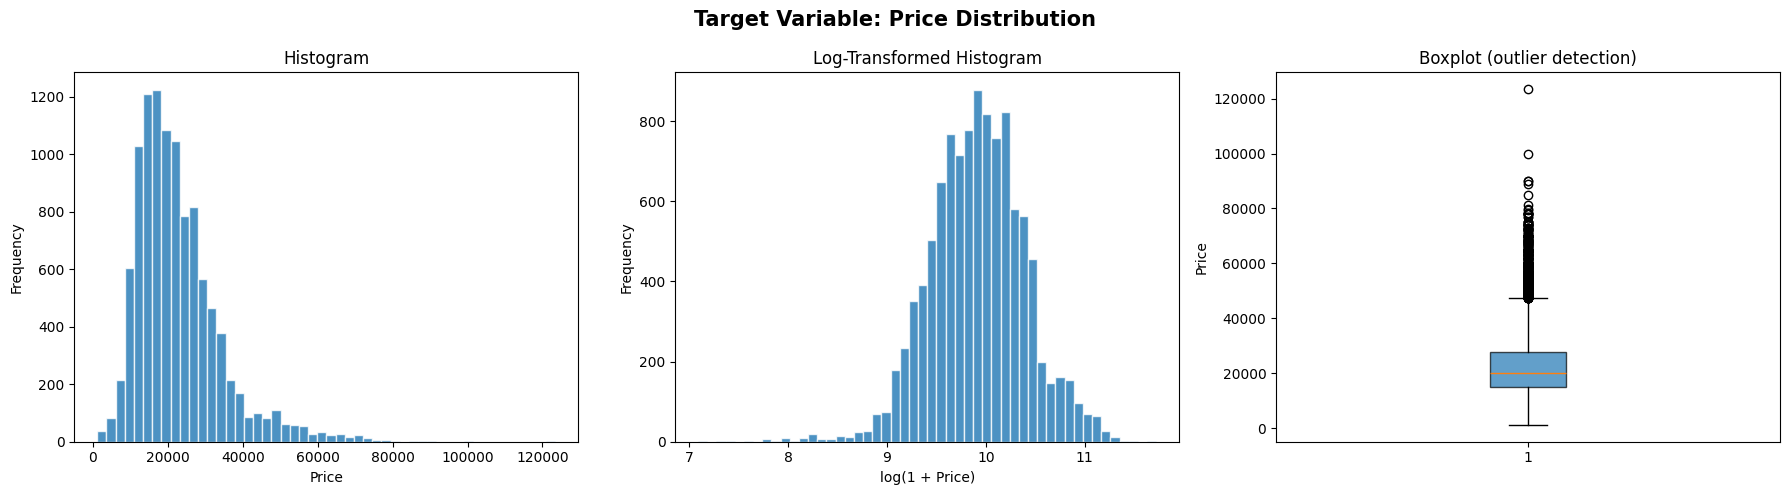

In [96]:
# Target Variable Distribution

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Target Variable: Price Distribution', fontsize=15, fontweight='bold')

# Histogram
axes[0].hist(df['price'], bins=50, edgecolor='white', alpha=0.8)
axes[0].set_title('Histogram')
axes[0].set_xlabel('Price')
axes[0].set_ylabel('Frequency')

# Log-transformed
log_price = np.log1p(df['price'])
axes[1].hist(log_price, bins=50, edgecolor='white', alpha=0.8)
axes[1].set_title('Log-Transformed Histogram')
axes[1].set_xlabel('log(1 + Price)')
axes[1].set_ylabel('Frequency')

# Box plot
axes[2].boxplot(df['price'], patch_artist=True,
                boxprops=dict(alpha=0.7))
axes[2].set_title('Boxplot (outlier detection)')
axes[2].set_ylabel('Price')

plt.tight_layout()
plt.show()


The distribution of the target variable (price) is strongly right-skewed, indicating that most vehicles are concentrated in the lower price range, while a smaller number of high-value cars create a long tail in the distribution.
Applying a logarithmic transformation significantly reduces skewness and results in a more symmetric distribution, which is beneficial for regression models that assume normality. We may also see the presence of many high-price outliers.

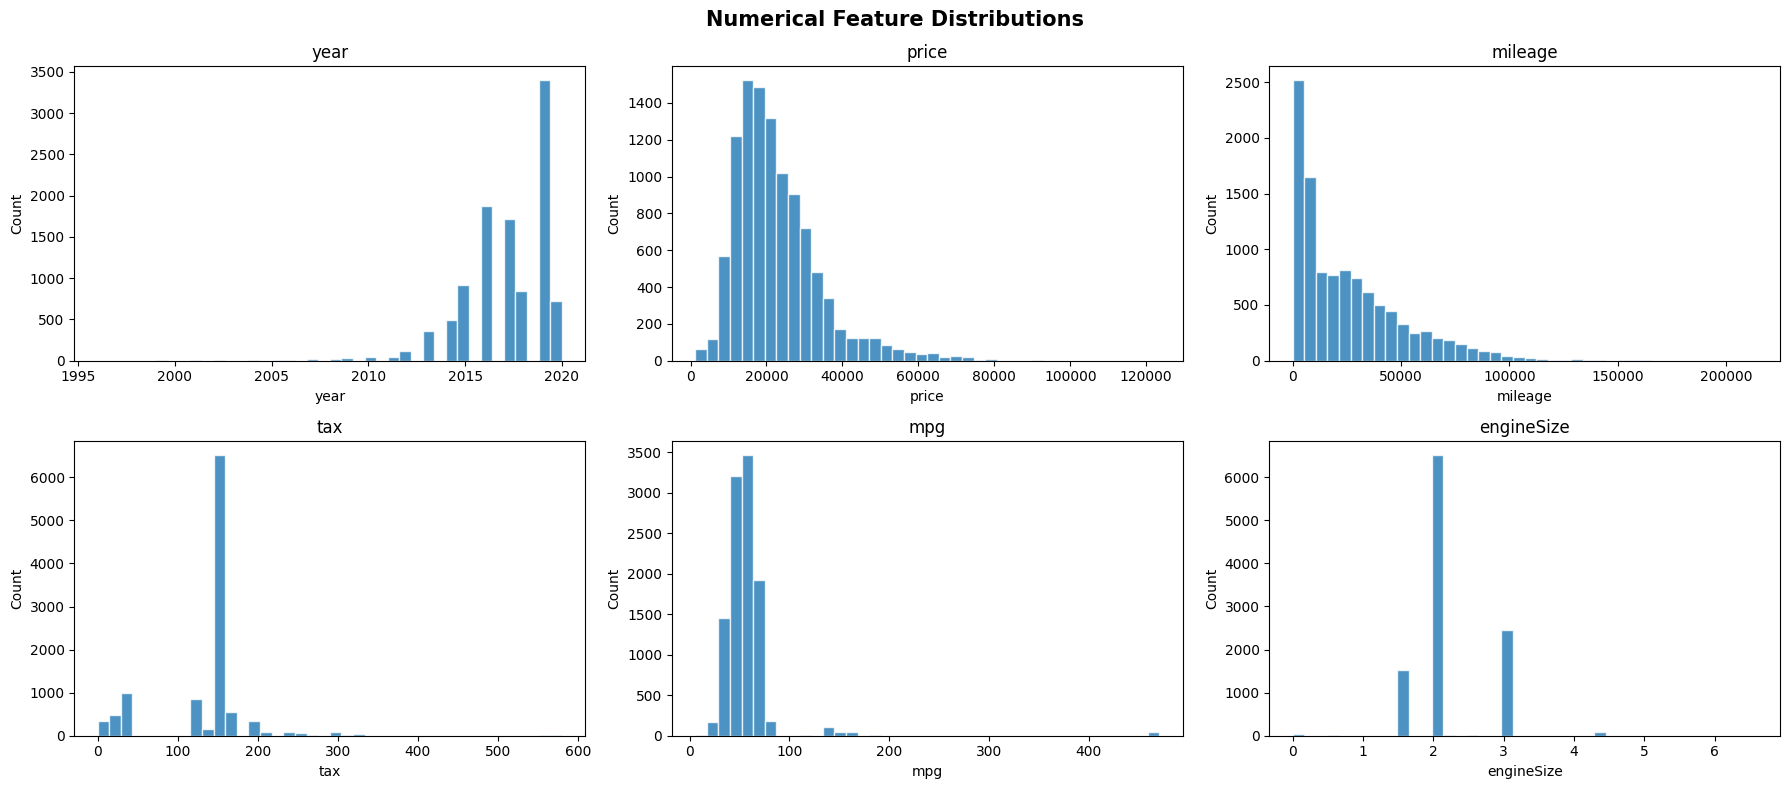

In [97]:
# Let's check Numerical Distributions
num_cols = df.select_dtypes(include=np.number).columns.tolist()
num_cols = [c for c in num_cols if c != 'Price']

n_cols_plot = 3
n_rows_plot = (len(num_cols) + n_cols_plot - 1) // n_cols_plot
fig, axes = plt.subplots(n_rows_plot, n_cols_plot, figsize=(18, 4 * n_rows_plot))
fig.suptitle('Numerical Feature Distributions', fontsize=15, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=40,
                 edgecolor='white', alpha=0.8)
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

- We may see diverse distributions, indicating varying levels of variability and data characteristics across variables
- The year variable is concentrated mostly between years: 2015-2020 suggesting that the dataset mainly contains newer vehicles, which may influence higher price levels
- Mileage shows right-skewed distribution with most vehicles having relatively low mileage and a few observations with very high values. This suggests that mileage is likely to be a key factor negatively affecting vehicle price
- Fuel economy (mpg) is mostly concentrated within a typical range, although some extreme values are present, which may represent outliers or special vehicle types
- Engine values are rather concentrated

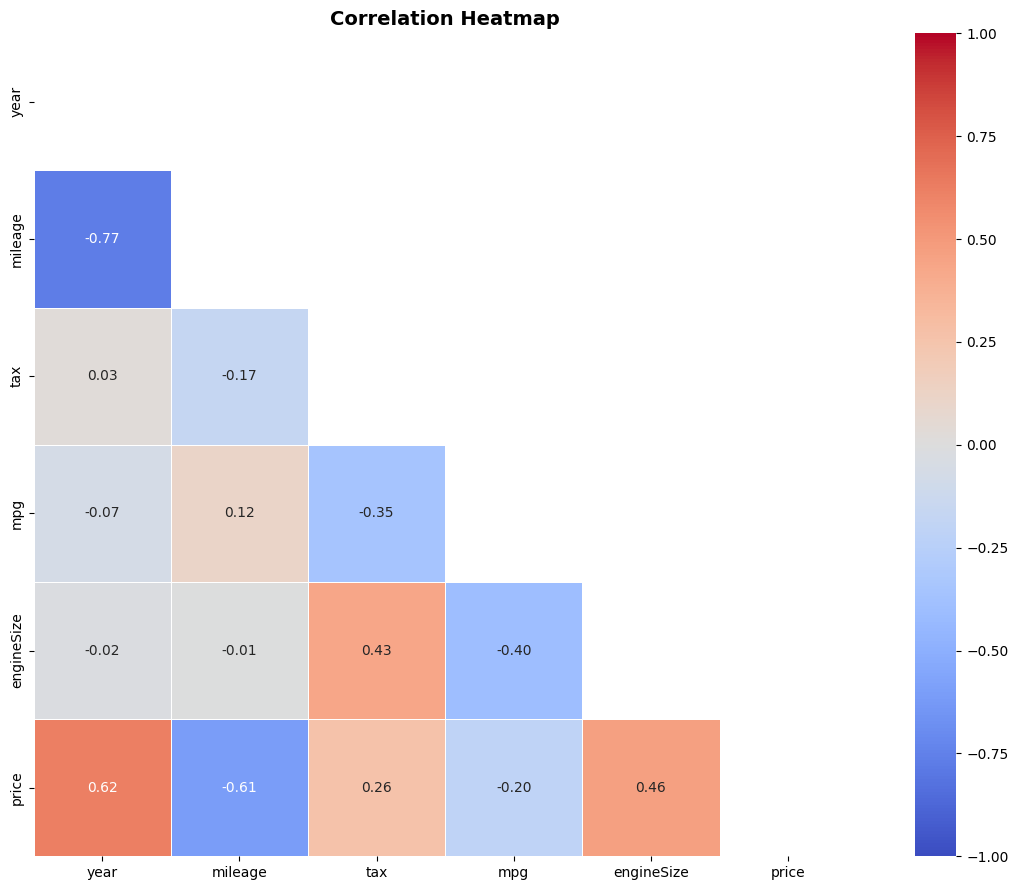

year          0.623754
mileage       0.605473
engineSize    0.461750
tax           0.264178
mpg           0.203986


In [98]:
# Correlation Heatmap

num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
num_cols = [c for c in num_cols if c != 'price']
corr_matrix = df[num_cols + ['price']].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, ax=ax,
            annot_kws={'size': 10})
ax.set_title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

target_corr = corr_matrix['price'].drop('price').abs().sort_values(ascending=False)
print(target_corr.to_string())

### Correlation Analysis

The correlation analysis reveals that there is a strong linear relationship between some features.

In particular, year and mileage show the highest correlations, indicating that newer vehicles tend to be more expensive, while higher mileage is associated with lower prices. Engine size also demonstrates a moderate positive correlation with price, suggesting that more powerful vehicles are generally more valuable.

Other variables such as tax and fuel economy (mpg) show weaker correlations, indicating a smaller direct influence on pricing.

We may now expect that both linear and non-linear models are about to give us competitive results.

# 📦 Section 4: Preprocessing and Feature Engineering

**Approach**:
- I am about to test both raw price and log1p(price) - log transformation often helps tree and neural models by reducing skewness
- Scaling: StandardScaler will be used for numerical features (critical for neural networks and distance-based models)
- Train / Validation / Test split: 70% / 15% / 15%

In [99]:
# Feature Engineering

# Let's make a copy to ensure that we are not messing the original dataframe
df_copy = df.copy()
df_copy.columns

Index(['model', 'year', 'price', 'transmission', 'mileage', 'fuelType', 'tax',
       'mpg', 'engineSize'],
      dtype='object')

In [100]:
# Car's age
df_copy['car_age'] = 2026 - df_copy['year']

In [101]:
# log mileage since our results are slightly skewed
df_copy['log_mileage'] = np.log1p(df_copy['mileage'])

In [102]:
# Price per engine size
df_copy['log_mileage'] = np.log1p(df_copy['mileage'])

In [103]:
# engine grouping
# df_copy['engine_category'] = pd.cut(df_copy['engineSize'],
#                               bins=[0, 1.6, 2.5, 4, 10],
#                               labels=[0, 1, 2, 3])

In [104]:
df_copy.dtypes

,0
model,object
year,int64
price,int64
transmission,object
mileage,int64
fuelType,object
tax,int64
mpg,float64
engineSize,float64
car_age,int64


In [105]:
# fuel efficiency ratio
df_copy['efficiency'] = df_copy['mpg'] / df_copy['engineSize']

In [106]:
# log target
df_copy['log_price'] = np.log1p(df_copy['price'])

In [107]:
df_copy.head(3)

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,car_age,log_mileage,efficiency,log_price
0,5 Series,2014,11200,Automatic,67068,Diesel,125,57.6,2.0,12,11.113477,28.800000,9.323758
1,6 Series,2018,27000,Automatic,14827,Petrol,145,42.8,2.0,8,9.604273,21.400000,10.203629
2,5 Series,2016,16000,Automatic,62794,Diesel,160,51.4,3.0,10,11.047631,17.133333,9.680406


In [108]:
# Object values -> dummies
obj_cols = df_copy.select_dtypes(include='object').columns
df_copy = pd.get_dummies(df_copy, columns=obj_cols, drop_first=True)

In [109]:
df_copy.head(2)

,year,price,mileage,tax,mpg,engineSize,car_age,log_mileage,efficiency,log_price,...,model_ Z3,model_ Z4,model_ i3,model_ i8,transmission_Manual,transmission_Semi-Auto,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol
0,2014,11200,67068,125,57.6,2.0,12,11.113477,28.8,9.323758,...,False,False,False,False,False,False,False,False,False,False
1,2018,27000,14827,145,42.8,2.0,8,9.604273,21.4,10.203629,...,False,False,False,False,False,False,False,False,False,True


In [111]:
# features / target
TARGET = "price"
LOG_TARGET = "log_price"
# X = df_copy.drop(columns=[TARGET, LOG_TARGET]).astype(float)
X = df_copy.drop(columns=[TARGET, LOG_TARGET])
y = df_copy[TARGET].astype(float)

# split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.1765, random_state=42)

# clean
X_train = X_train.replace([np.inf, -np.inf], np.nan)
X_val   = X_val.replace([np.inf, -np.inf], np.nan)
X_test  = X_test.replace([np.inf, -np.inf], np.nan)

X_train = X_train.fillna(X_train.median())
X_val   = X_val.fillna(X_train.median())
X_test  = X_test.fillna(X_train.median())

# scaling
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

# target
y_train_log = np.log1p(y_train)
y_val_log   = np.log1p(y_val)
y_test_log  = np.log1p(y_test)

# 📦 Section 5: Basic ML Models
I am about to start with classical ML models to establish strong baseline and to check how our dataset responds with simple ML solutions.

**MODELS**:
1. Linear Regression (with and without regularization: Lasso)
2. Decision Tree Regressor
3. Random Forest Regressor
4. XGBoost Regressor

❗All models are evaluated using 5-fold cross-validation(CV) on the training set, then final metrics on the held-out test set.

In [112]:
# evaluation function helper
final_results = {}

def evaluate_model(name, model, X_train, y_train, X_test, y_test,
                   cv_folds=5, log_target=False):
    """Fit, cross-validate, and evaluate a model. Returns dict of metrics."""
    # cross validation
    kf = KFold(n_splits=cv_folds, shuffle=True, random_state=42)
    cv_scores = cross_val_score(model, X_train, y_train, cv=kf,
                                scoring='neg_root_mean_squared_error')
    cv_rmse = -cv_scores

    # fit on full training set
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test) # prediction

    if log_target:
        y_pred = np.expm1(y_pred)
        y_test   = np.expm1(y_test)

    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    test_mae  = mean_absolute_error(y_test, y_pred)
    test_r2   = r2_score(y_test, y_pred)

    print(f'model: {name}')
    print(f'  CV RMSE:   {cv_rmse.mean():.3f} +- {cv_rmse.std():.3f}')
    print(f'  Test RMSE: {test_rmse:.3f}')
    print(f'  test MAE:  {test_mae:.3f}')
    print(f'  Test R*R:   {test_r2:.4f}\n')
    print(f'  Overfitting gap: {abs(cv_rmse.mean() - test_rmse):.3f}')

    final_results[name] = {
        'cv_rmse_mean': cv_rmse.mean(),
        'cv_rmse_std':  cv_rmse.std(),
        'test_rmse':    test_rmse,
        'test_mae':     test_mae,
        'test_r2':      test_r2
        # 'y_pred':       y_pred too long
    }
    return final_results[name]


In [113]:
#linear models
evaluate_model('Linear Regression',LinearRegression(), X_train_s, y_train, X_test_s, y_test)
evaluate_model('Lasso (alpha=1.0)', Lasso(alpha=1.0, max_iter=5000), X_train_s, y_train, X_test_s, y_test)

model: Linear Regression
  CV RMSE:   4075.722 +- 491.507
  Test RMSE: 4175.671
  test MAE:  2708.888
  Test R*R:   0.8589

  Overfitting gap: 99.949
model: Lasso (alpha=1.0)
  CV RMSE:   4075.765 +- 491.473
  Test RMSE: 4175.972
  test MAE:  2709.667
  Test R*R:   0.8589

  Overfitting gap: 100.207


{'cv_rmse_mean': np.float64(4075.7648498605313),
 'cv_rmse_std': np.float64(491.472888569802),
 'test_rmse': np.float64(4175.971943736629),
 'test_mae': 2709.666734428401,
 'test_r2': 0.8589103241895415}

text coming soon

In [114]:
# Decision Tree with different depth in second example since depth limit prevents overfitting
evaluate_model('Decision Tree (default)',
               DecisionTreeRegressor(random_state=42),
               X_train, y_train, X_test, y_test)

evaluate_model('Decision Tree with max_depth=8',
               DecisionTreeRegressor(max_depth=8, min_samples_leaf=10, random_state=42),
               X_train, y_train, X_test, y_test)


model: Decision Tree (default)
  CV RMSE:   3560.576 +- 636.372
  Test RMSE: 2998.093
  test MAE:  1953.602
  Test R*R:   0.9273

  Overfitting gap: 562.483
model: Decision Tree with max_depth=8
  CV RMSE:   4086.181 +- 397.195
  Test RMSE: 3645.949
  test MAE:  2284.906
  Test R*R:   0.8925

  Overfitting gap: 440.232


{'cv_rmse_mean': np.float64(4086.180595414541),
 'cv_rmse_std': np.float64(397.19453971985837),
 'test_rmse': np.float64(3645.948611050778),
 'test_mae': 2284.905604723366,
 'test_r2': 0.892452287559377}

text coming sooon

In [115]:
evaluate_model('Random Forest 100 trees',
               RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
               X_train, y_train, X_test, y_test)

evaluate_model('Random Forest 200 trees',
               RandomForestRegressor(n_estimators=200, max_depth=15,
                                     min_samples_leaf=5, random_state=42, n_jobs=-1),
               X_train, y_train, X_test, y_test)

model: Random Forest 100 trees
  CV RMSE:   2773.630 +- 558.304
  Test RMSE: 2433.922
  test MAE:  1533.771
  Test R*R:   0.9521

  Overfitting gap: 339.709
model: Random Forest 200 trees
  CV RMSE:   3218.179 +- 485.993
  Test RMSE: 2937.277
  test MAE:  1658.026
  Test R*R:   0.9302

  Overfitting gap: 280.902


{'cv_rmse_mean': np.float64(3218.179056478464),
 'cv_rmse_std': np.float64(485.992887973212),
 'test_rmse': np.float64(2937.2768543066604),
 'test_mae': 1658.0260822325065,
 'test_r2': 0.9301976800130305}

soon soon

In [116]:
evaluate_model('XGBoost (default)',
               xgb.XGBRegressor(objective='reg:squarederror',
                                random_state=42, verbosity=0),
               X_train, y_train, X_test, y_test)

evaluate_model('XGBoost (tuned)',
               xgb.XGBRegressor(objective='reg:squarederror',
                                n_estimators=300, max_depth=6,
                                learning_rate=0.05, subsample=0.8,
                                colsample_bytree=0.8, reg_alpha=0.1,
                                reg_lambda=1.0, random_state=42, verbosity=0),
               X_train, y_train, X_test, y_test)

model: XGBoost (default)
  CV RMSE:   2757.178 +- 556.950
  Test RMSE: 2440.976
  test MAE:  1499.652
  Test R*R:   0.9518

  Overfitting gap: 316.202
model: XGBoost (tuned)
  CV RMSE:   2666.874 +- 561.563
  Test RMSE: 2312.608
  test MAE:  1486.422
  Test R*R:   0.9567

  Overfitting gap: 354.267


{'cv_rmse_mean': np.float64(2666.874392411858),
 'cv_rmse_std': np.float64(561.5630407203417),
 'test_rmse': np.float64(2312.6076341355374),
 'test_mae': 1486.4215983581544,
 'test_r2': 0.9567302883480461}

soooon

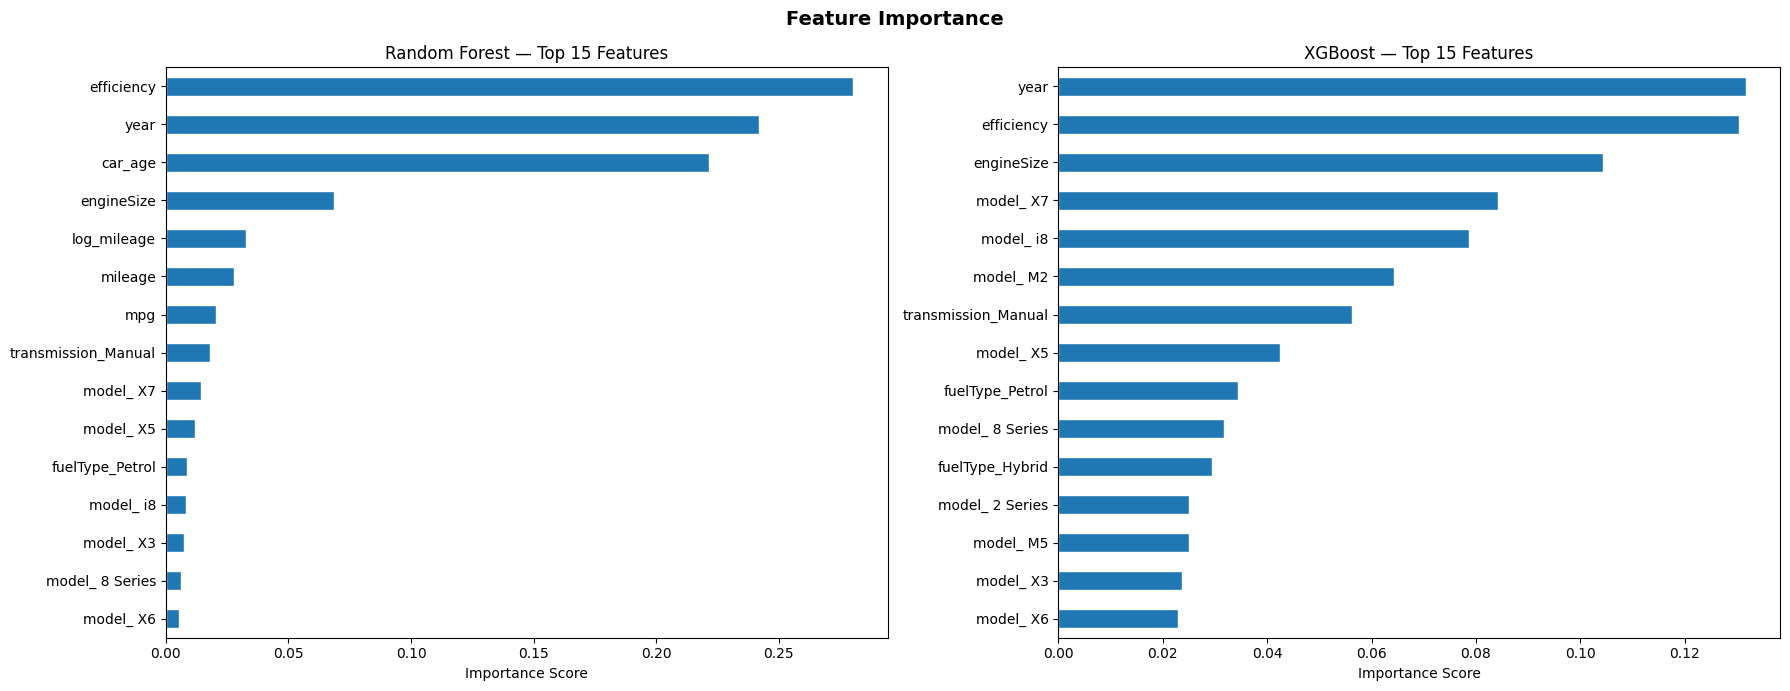

In [117]:
# Random Forest & XGBoost
rf_model = RandomForestRegressor(n_estimators=200, max_depth=15,
                                  min_samples_leaf=5, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

xgb_model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=300,
                               max_depth=6, learning_rate=0.05, random_state=42, verbosity=0)
xgb_model.fit(X_train, y_train)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Feature Importance', fontsize=14, fontweight='bold')

for ax, model, name in [(axes[0], rf_model, 'Random Forest'),
                         (axes[1], xgb_model, 'XGBoost')]:
    importances = pd.Series(model.feature_importances_,
                             index=X_train.columns).sort_values(ascending=True).tail(15)
    importances.plot(kind='barh', ax=ax, edgecolor='white')
    ax.set_title(f'{name} — Top 15 Features', fontsize=12)
    ax.set_xlabel('Importance Score')

plt.tight_layout()
plt.show()
